<a href="https://colab.research.google.com/github/chittimella-srinikitha/Data-Analytics-Projects-UM-/blob/main/Road_accidents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Objective:**

Build a two-part analysis for US traffic accidents:

1. Classify accident severity (binary: low vs high) using time, location, and weather features to help emergency services prioritize response and insurers estimate risk.

2. Identify geo-temporal hotspots (cluster analysis + heatmaps) and produce a monthly trend dashboard so city planners and transport ops can allocate resources and reduce risk.


In [ ]:
import pandas as pd

df = pd.read_csv('/content/US_Accidents_March23_sampled_500k.csv')
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-2047758,Source2,2,2019-06-12 10:10:56,2019-06-12 10:55:58,30.641211,-91.153481,NaN,NaN,0.000,...,False,False,False,False,True,False,Day,Day,Day,Day
1,A-4694324,Source1,2,2022-12-03 23:37:14.000000000,2022-12-04 01:56:53.000000000,38.990562,-77.399070,38.990037,-77.398282,0.056,...,False,False,False,False,False,False,Night,Night,Night,Night
2,A-5006183,Source1,2,2022-08-20 13:13:00.000000000,2022-08-20 15:22:45.000000000,34.661189,-120.492822,34.661189,-120.492442,0.022,...,False,False,False,False,True,False,Day,Day,Day,Day
3,A-4237356,Source1,2,2022-02-21 17:43:04,2022-02-21 19:43:23,43.680592,-92.993317,43.680574,-92.972223,1.054,...,False,False,False,False,False,False,Day,Day,Day,Day
4,A-6690583,Source1,2,2020-12-04 01:46:00,2020-12-04 04:13:09,35.395484,-118.985176,35.395476,-118.985995,0.046,...,False,False,False,False,False,False,Night,Night,Night,Night


**Basic Cleaning**

In [ ]:
#Keep only relevant columns
cols_needed = [
    'ID','Source','TMC','Severity','Start_Time','End_Time',
    'Start_Lat','Start_Lng','End_Lat','End_Lng',
    'Distance(mi)','Description','Number','Street','Side',
    'City','County','State','Zipcode','Country',
    'Timezone','Airport_Code','Temperature(F)','Weather_Condition',
    'Wind_Chill(F)','Wind_Direction','Wind_Speed(mph)','Precipitation(in)',
    'Visibility(mi)','Sunrise_Sunset','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight'
]
# Keep intersecting columns to be safe
cols = [c for c in cols_needed if c in df.columns]
df = df[cols].copy()
print("Columns used:", len(cols))

Columns used: 30


In [ ]:
# Drop rows with no coordinates
df = df.dropna(subset=['Start_Lat','Start_Lng'])
# Convert Severity - ensure numeric
df['Severity'] = pd.to_numeric(df['Severity'], errors='coerce')
df = df.dropna(subset=['Severity'])

# Parse Start_Time if not already
if df['Start_Time'].dtype == object:
    df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
if 'End_Time' in df.columns and df['End_Time'].dtype == object:
    df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')

In [ ]:
df.isna().sum()

,0
ID,0
Source,0
Severity,0
Start_Time,48163
End_Time,48163
Start_Lat,0
Start_Lng,0
End_Lat,220377
End_Lng,220377
Distance(mi),0


In [ ]:
categorical_data = ["Sunrise_Sunset", "Civil_Twilight","Nautical_Twilight",
                    "Astronomical_Twilight","Country", "Street", "City", "Airport_Code",
                    "Timezone", "Zipcode","Wind_Direction", "Weather_Condition","Description"]

# converting all categorical data and replace its missing values with mode
for col in categorical_data:
    df[col] = df[col].fillna(df[col].mode()[0])

numeric_cols = ['Temperature(F)', 'Visibility(mi)', 'Precipitation(in)', 'Wind_Speed(mph)', 'Wind_Chill(F)']

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df.isna().sum()

,0
ID,0
Source,0
Severity,0
Start_Time,48163
End_Time,48163
Start_Lat,0
Start_Lng,0
End_Lat,220377
End_Lng,220377
Distance(mi),0


**Feature Engineering**

In [ ]:
df['hour'] = df['Start_Time'].dt.hour
df['weekday'] = df['Start_Time'].dt.weekday
df['month'] = df['Start_Time'].dt.month
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)
df['is_night'] = df['hour'].apply(lambda x: 1 if (x<6 or x>=20) else 0)

# Weather: keep main categories (simplify)
if 'Weather_Condition' in df.columns:
    df['Weather_Condition'] = df['Weather_Condition'].fillna('Unknown')
    # simplify by keeping first token, lowercase
    df['Weather_basic'] = df['Weather_Condition'].str.lower().str.split().str[0].fillna('unknown')

# Temperature, Visibility numeric
for col in ['Temperature(F)','Visibility(mi)','Wind_Speed(mph)','Precipitation(in)']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with missing lat/lng
df.dropna(subset=['Start_Lat', 'Start_Lng', 'Start_Time', 'End_Time'], inplace=True)
print("After basic cleaning rows:", len(df))

After basic cleaning rows: 451837


**Exploratory Data Analysis**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

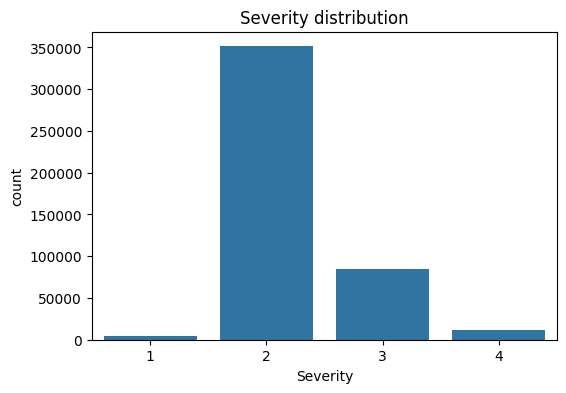

In [ ]:
# Severity distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Severity', data=df)
plt.title('Severity distribution')
plt.show()

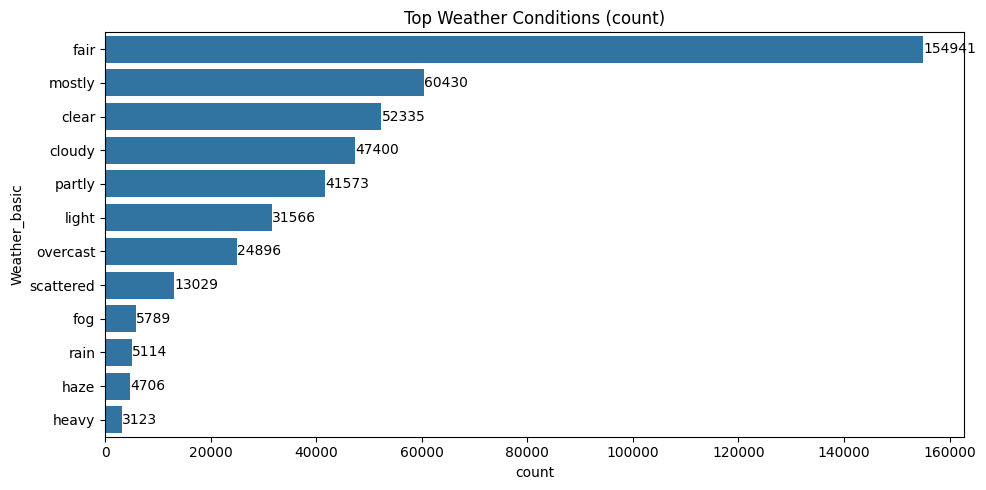

In [ ]:
# Severity by weather (top categories)
if 'Weather_basic' in df.columns:
    topweather = df['Weather_basic'].value_counts().nlargest(12).index

    plt.figure(figsize=(10,5))
    ax = sns.countplot(
        y='Weather_basic',
        data=df[df['Weather_basic'].isin(topweather)],
        order=topweather
    )

    plt.title('Top Weather Conditions (count)')

    # Add counts on bars
    for p in ax.patches:
        width = p.get_width()
        ax.text(
            width + 50,
            p.get_y() + p.get_height()/2,
            int(width),
            va='center'
        )

    plt.tight_layout()
    plt.show()

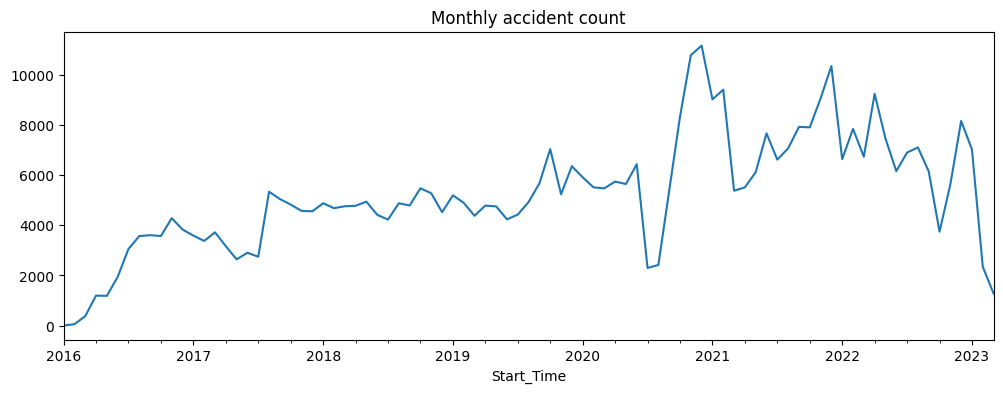

In [ ]:
# Monthly trend (sample to speed)
monthly = df.groupby(df['Start_Time'].dt.to_period('M')).size().astype(int)
monthly.plot(kind='line', figsize=(12,4), title='Monthly accident count')
plt.show()

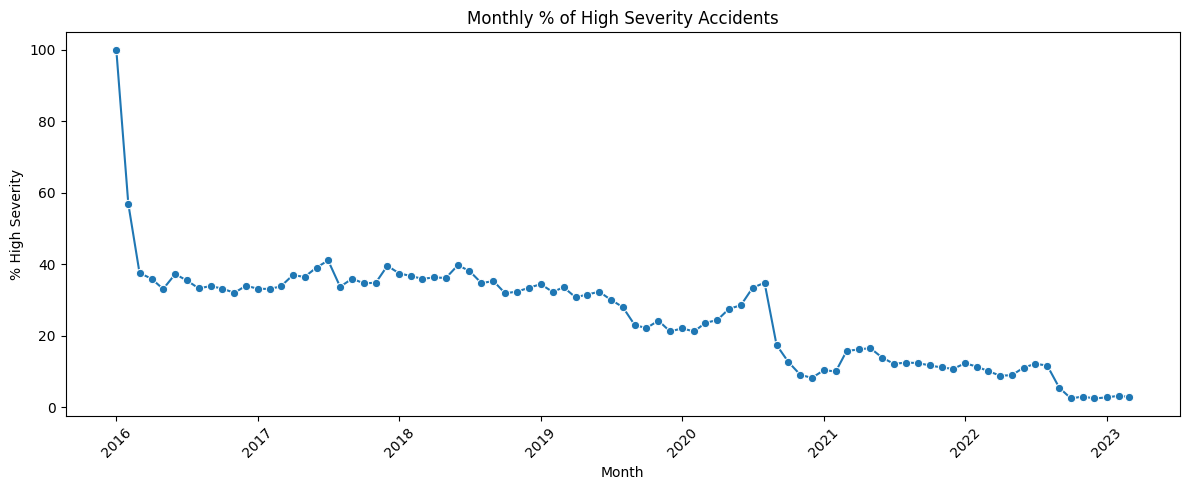

In [ ]:
#Time-series: monthly high-severity rate
df['sev_high'] = (df['Severity'] >= 3).astype(int)
df['month_period'] = df['Start_Time'].dt.to_period('M')
monthly_sev = df.groupby('month_period').agg(total=('ID','count'), high_sev=('sev_high','sum')).reset_index()
monthly_sev['high_sev_pct'] = 100.0 * monthly_sev['high_sev'] / monthly_sev['total']
monthly_sev['month_period'] = monthly_sev['month_period'].dt.to_timestamp()

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_sev, x='month_period', y='high_sev_pct', marker='o')
plt.title('Monthly % of High Severity Accidents')
plt.ylabel('% High Severity')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()